In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
def zdiv(a, b):
    if b == 0:
        return 0
    return a / b


def N0(_knots, i, x):
    if i + 1 < len(_knots) - 1:
        supported = np.logical_and(_knots[i] <= x, x < _knots[i + 1])
    else:
        supported = np.logical_and(_knots[i] <= x, x <= _knots[i + 1])
    return supported.astype(float)


def N1(_knots, i, x):
    k = _knots
    p = 1
    return (
            zdiv(x - k[i], k[i + p] - k[i]) * N0(k, i, x) +
            zdiv(k[i + p + 1] - x, k[i + p + 1] - k[i + 1]) * N0(k, i + 1, x)
    )


def N2(_knots, i, x):
    k = _knots
    p = 2
    return (
            zdiv(x - k[i], k[i + p] - k[i]) * N1(k, i, x) +
            zdiv(k[i + p + 1] - x, k[i + p + 1] - k[i + 1]) * N1(k, i + 1, x)
    )

def plot_basis(_knots, _x):
    m = len(knots) - 1
    for i in range(m):
        plt.plot(_x, N0(_knots, i, _x))
    plt.vlines(_knots, 0, 1, linestyles="--", color="grey")
    plt.show()

    for i in range(m-1):
        plt.plot(_x, N1(_knots, i, _x))
    plt.vlines(_knots, 0, 1, linestyles="--", color="grey")
    plt.show()

    for i in range(m-2):
        plt.plot(_x, N2(_knots, i, _x))
    plt.vlines(_knots, 0, 1, linestyles="--", color="grey")
    plt.show()

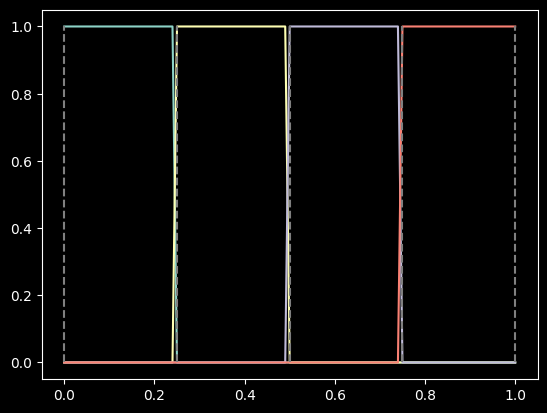

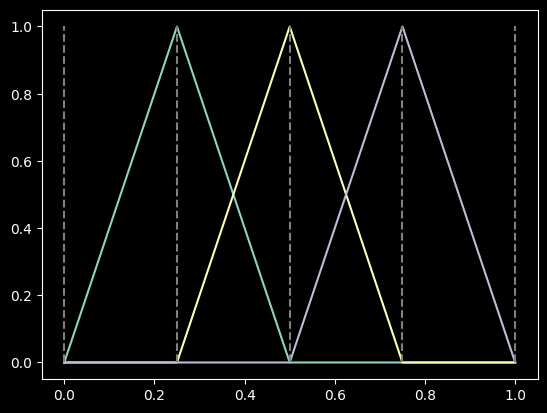

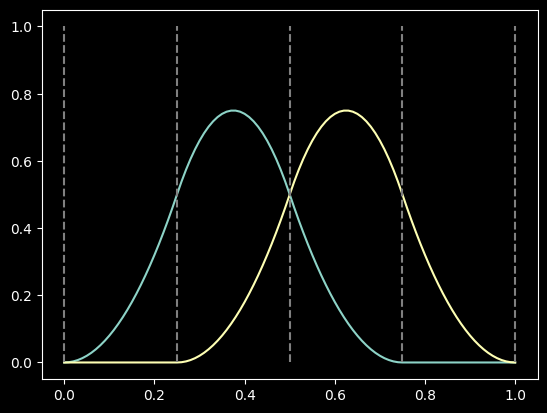

In [39]:
knots = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
x = np.linspace(0, 1, 101)
plot_basis(knots, x)


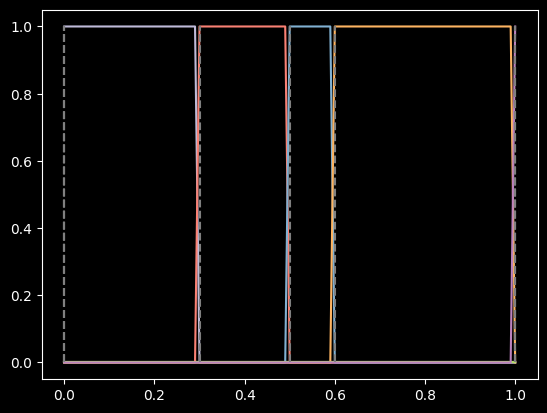

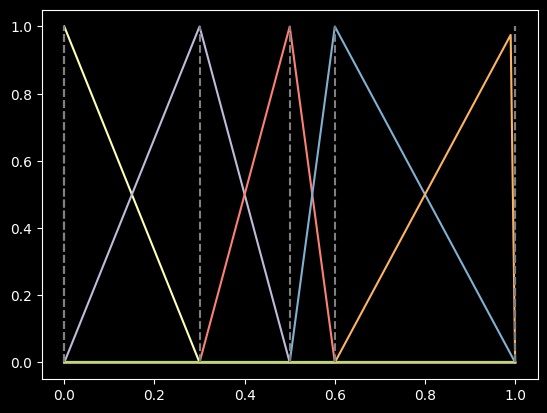

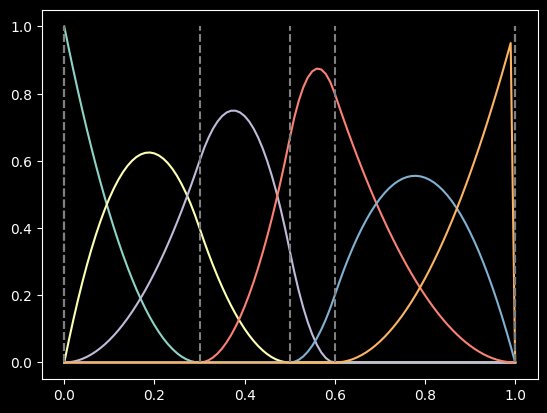

In [49]:
knots = np.array([0.0, 0.0, 0.0, 0.3, 0.5, 0.6, 1.0, 1.0, 1.0])
x = np.linspace(0, 1, 101)
plot_basis(knots, x)